# Amazon US BSR Share 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math
from datetime import date

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
sql = f"""
select * from wook.amz_us_bsr_add_seller_price_rating
where bsr_ctgry in ('Mattresses','Beds','Bed Frames')
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
print(df)

       parent_asin   bsr_ctgry        asin  rank    bsr_date           brand  \
0       B0D5RC39TY        Beds  B079PG6VMW    32  2022-09-12          Others   
1       B07RFGWXNM  Bed Frames  B07RFGWXNM     8  2022-09-12          Others   
2       B0FR9HNG1V  Mattresses  B07BV29J5N    23  2022-09-12        COOL GEL   
3       B0CTR6GDNQ  Bed Frames  B08VN6W69N    15  2022-09-12       YAHEETECH   
4       B09X75ZWGG        Beds  B004LQ1PAI    28  2022-09-12          Others   
...            ...         ...         ...   ...         ...             ...   
325851  B0DYZ28XZV  Mattresses  B074QTSBS2     2  2021-01-01           ZINUS   
325852  B0D5B3DVZL        Beds  B07S6SDM2V    18  2021-01-01          Others   
325853  B08C2RJTLY  Bed Frames  B08C2RJTLY    42  2021-01-01  AMOLIFE FAMILY   
325854  B0B3DC36K1        Beds  B00TPI7JNO    22  2021-01-01          Others   
325855  B07YQN9R32        Beds  B06WW5586Q    32  2021-01-01           ZINUS   

        brand_raw brand_raw_org  \
0   

In [11]:
sql = f"""
select * from stck.atlas_sales_all 
where SubCategory in ('Mattresses','Beds','Bed Frames') and WeekId >= 202501
"""

df_sales = bqclient.query(sql).to_dataframe()

In [13]:
print(df_sales)

        RetailerId RetailerName RetailerSku  upc   ModelNumber  \
0                1   Amazon.com  B0C148M3VX  NaN    RWO-10INCH   
1                1   Amazon.com  B0D3PHY35S  NaN          None   
2                1   Amazon.com  B0D3L5JY1X  NaN       10 Inch   
3                1   Amazon.com  B0CT33XBYT  NaN          None   
4                1   Amazon.com  B0B8J1KRDS  NaN          None   
...            ...          ...         ...  ...           ...   
982733           1   Amazon.com  B0DPK173DH  NaN        SF-12Q   
982734           1   Amazon.com  B0DP9DW71C  NaN        SF-12Q   
982735           1   Amazon.com  B0BVZLMVKF  NaN  DRE-FULL-8IN   
982736           1   Amazon.com  B0CYT7ZT1R  NaN         92552   
982737           1   Amazon.com  B09N6LVKX7  NaN         92550   

                                                    Title           Brand  \
0       10 Inch Bed Frame Full Metal Platform Mattress...      Richwanone   
1       10 Inch California King Bed Frame with Steel 

In [25]:
df1 = df.copy()
#df1.info()

df1['bsr_date'] = pd.to_datetime(df1['bsr_date'], errors='coerce')
df1['year'] = df1['bsr_date'].dt.year
df1.head(3)

,parent_asin,bsr_ctgry,asin,rank,bsr_date,brand,brand_raw,brand_raw_org,title,image_url,...,asin_cnt_brand_dt,asin_cnt_brand_dt_rank,asin_cnt_ttl_dt,asin_cnt_ttl_dt_rank,brand_legend_ord,retail_price,rating,review_count,seller_type,year
0,B0D5RC39TY,Beds,B079PG6VMW,32,2022-09-12,Others,Others,MAX & LILY,"Max &amp; Lily Low Bunk Bed, Twin, White",https://images-na.ssl-images-amazon.com/images...,...,26,0,50,0,99999999,NaN,NaN,NaN,None,2022
1,B07RFGWXNM,Bed Frames,B07RFGWXNM,8,2022-09-12,Others,Others,HAAGEEP,HAAGEEP Black Full Bed Frame No Box Spring Nee...,https://images-na.ssl-images-amazon.com/images...,...,19,1,50,0,99999999,NaN,NaN,NaN,None,2022
2,B0FR9HNG1V,Mattresses,B07BV29J5N,23,2022-09-12,COOL GEL,COOL GEL,COOL GEL,Cool Gel Chill 14 Inch Medium Firm Memory Foam...,https://m.media-amazon.com/images/I/81G4EIjwEG...,...,3,1,50,0,130,NaN,NaN,NaN,None,2022


In [27]:
def get_brand_share_by_category(
    df,
    category,
    year=2025,
    category_col='bsr_ctgry',
    brand_col='brand_raw_org',
    top_n=10,
    exclude_others=True
):
    """
    특정 category(bsr_ctgry) 기준으로
    - brand BSR 노출 수
    - category 내 brand share 계산
    - Top N 브랜드 반환
    """

    # === 1. 연도 + 카테고리 필터 ===
    df_use = df[
        (df['year'] == year) &
        (df[category_col] == category)
    ].copy()

    if df_use.empty:
        print(f"[INFO] No data for category='{category}', year={year}")
        return pd.DataFrame()

    # === 2. (category, brand) BSR 노출 횟수 ===
    brand_cnt = (
        df_use
        .groupby(brand_col)
        .size()
        .reset_index(name='bsr_cnt')
    )

    # === 3. category 기준 share 계산 ===
    brand_share = (
        brand_cnt
        .assign(
            cat_total_cnt=lambda x: x['bsr_cnt'].sum(),
            bsr_share=lambda x: x['bsr_cnt'] / x['cat_total_cnt'],
            bsr_share_pct=lambda x: x['bsr_share'] * 100
        )
        .sort_values('bsr_share', ascending=False)
    )
    #print(brand_share)

    # === 4. Others 제외 옵션 ===
#    if exclude_others:
#        brand_share = brand_share[
#            brand_share[brand_col] != 'Others'
#        ]
    
    # === 5. Top N ===
    result = brand_share.head(top_n)
    return result

In [29]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_base_2025 = {
    cat: get_brand_share_by_category(df1, category=cat, year=2025)
    for cat in categories
}

In [31]:
top10_base_2025['Mattresses']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
171,ZINUS,2724,19691,0.138337,13.833731
103,NOVILLA,1885,19691,0.095729,9.572901
91,MLILY,1317,19691,0.066883,6.688335
15,BEST PRICE MATTRESS,490,19691,0.024884,2.488446
123,ROLANSTAR,447,19691,0.022701,2.270073
4,AMAZON BASICS,397,19691,0.020161,2.016150
93,MOLBIUS,395,19691,0.020060,2.005993
95,NAPQUEEN,378,19691,0.019197,1.919659
52,FDW,370,19691,0.018790,1.879031
56,GAESTE,368,19691,0.018689,1.868874


#### 1. 월별 점유율 계산하기

In [130]:
# result_all 값을 기준으로 is_top10 컬럼만들기 
rows = []
for cat, topdf in top10_base_2025.items():
    brands = topdf['brand_raw_org']
    #brands = brands.dropna().astype(str).unique().tolist()
    rows.extend([(cat, b) for b in brands])
#print(rows)

top_map = (
    pd.DataFrame(rows, columns=['bsr_ctgry', 'brand_raw_org'])
    .drop_duplicates()
)
top_map['is_top10'] = 1
print(top_map)

df_w_top = df1.merge( top_map, on=['bsr_ctgry', 'brand_raw_org'], how='left')
df_w_top['brand_new'] = df_w_top['brand_raw_org'].where(df_w_top['is_top10']==1, 'OTHERS')
print(df_w_top)

     bsr_ctgry        brand_raw_org  is_top10
0         Beds                ZINUS         1
1         Beds               DICTAC         1
2         Beds           SHA CERLIN         1
3         Beds             ADORNEVE         1
4         Beds             AMERLIFE         1
5         Beds               VINGLI         1
6         Beds             JOCOEVOL         1
7         Beds              MIXCOUS         1
8         Beds              ALLEWIE         1
9         Beds           STORKCRAFT         1
10  Bed Frames              ALLEWIE         1
11  Bed Frames                ZINUS         1
12  Bed Frames             FURNULEM         1
13  Bed Frames            YAHEETECH         1
14  Bed Frames           SHA CERLIN         1
15  Bed Frames        AMAZON BASICS         1
16  Bed Frames                OLEVS         1
17  Bed Frames               VECELO         1
18  Bed Frames              NOVILLA         1
19  Bed Frames               FLUEST         1
20  Mattresses                ZINU

In [138]:
# 1) Top10 row만 필터
#df_top = df_w_top[df_w_top['is_top10'] == 1].copy()

# 2) (category, brand)별 노출 횟수
brand_cnt_m = (
    df_w_top
    .groupby(['bsr_ctgry', 'yr_month', 'brand_new'])
    .size()
    .reset_index(name='bsr_cnt')
)
print(brand_cnt_m)

# 3) (category, year_month)별 분모 계산 + share
brand_share_m = (
    brand_cnt_m
    .assign(
        month_total_cnt=lambda x: x.groupby(['bsr_ctgry', 'yr_month'])['bsr_cnt'].transform('sum'),
        bsr_share=lambda x: x['bsr_cnt'] / x['month_total_cnt'],
       # bsr_share_pct=lambda x: x['bsr_share'] * 100
    )
    .sort_values(['bsr_ctgry', 'yr_month', 'bsr_share'], ascending=[True, True, False])
)

brand_share_m[brand_share_m['brand_new']=='OTHERS']

       bsr_ctgry yr_month      brand_new  bsr_cnt
0     Bed Frames    21-01        ALLEWIE       68
1     Bed Frames    21-01  AMAZON BASICS       92
2     Bed Frames    21-01         OTHERS      782
3     Bed Frames    21-01     SHA CERLIN       12
4     Bed Frames    21-01         VECELO       24
...          ...      ...            ...      ...
1417  Mattresses    25-12       NAPQUEEN       25
1418  Mattresses    25-12        NOVILLA      121
1419  Mattresses    25-12         OTHERS      692
1420  Mattresses    25-12      ROLANSTAR       23
1421  Mattresses    25-12          ZINUS      101

[1422 rows x 4 columns]


,bsr_ctgry,yr_month,brand_new,bsr_cnt,month_total_cnt,bsr_share
2,Bed Frames,21-01,OTHERS,782,1400,0.558571
8,Bed Frames,21-02,OTHERS,675,1400,0.482143
14,Bed Frames,21-03,OTHERS,745,1549,0.480955
20,Bed Frames,21-04,OTHERS,711,1500,0.474000
27,Bed Frames,21-05,OTHERS,617,1499,0.411608
...,...,...,...,...,...,...
1376,Mattresses,25-08,OTHERS,898,1635,0.549235
1387,Mattresses,25-09,OTHERS,859,1537,0.558881
1398,Mattresses,25-10,OTHERS,932,1649,0.565191
1408,Mattresses,25-11,OTHERS,940,1633,0.575628


['ZINUS', 'ALLEWIE', 'FURNULEM', 'YAHEETECH', 'SHA CERLIN', 'AMAZON BASICS', 'OLEVS', 'VECELO', 'NOVILLA', 'FLUEST', 'OTHERS']


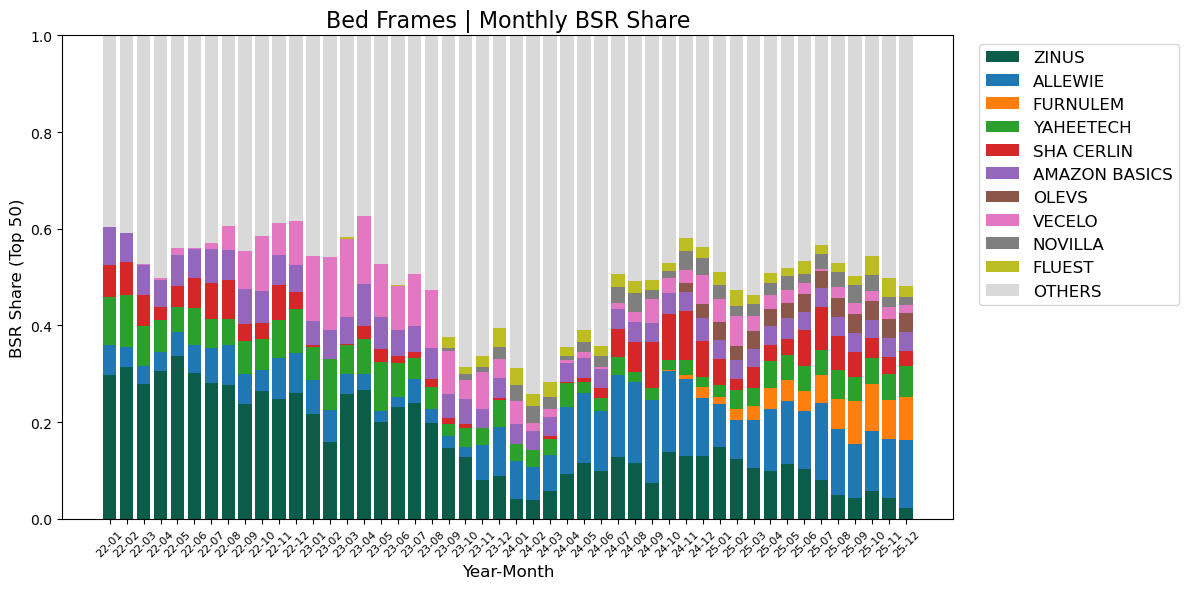

['ZINUS', 'DICTAC', 'SHA CERLIN', 'ADORNEVE', 'AMERLIFE', 'VINGLI', 'JOCOEVOL', 'MIXCOUS', 'ALLEWIE', 'STORKCRAFT', 'OTHERS']


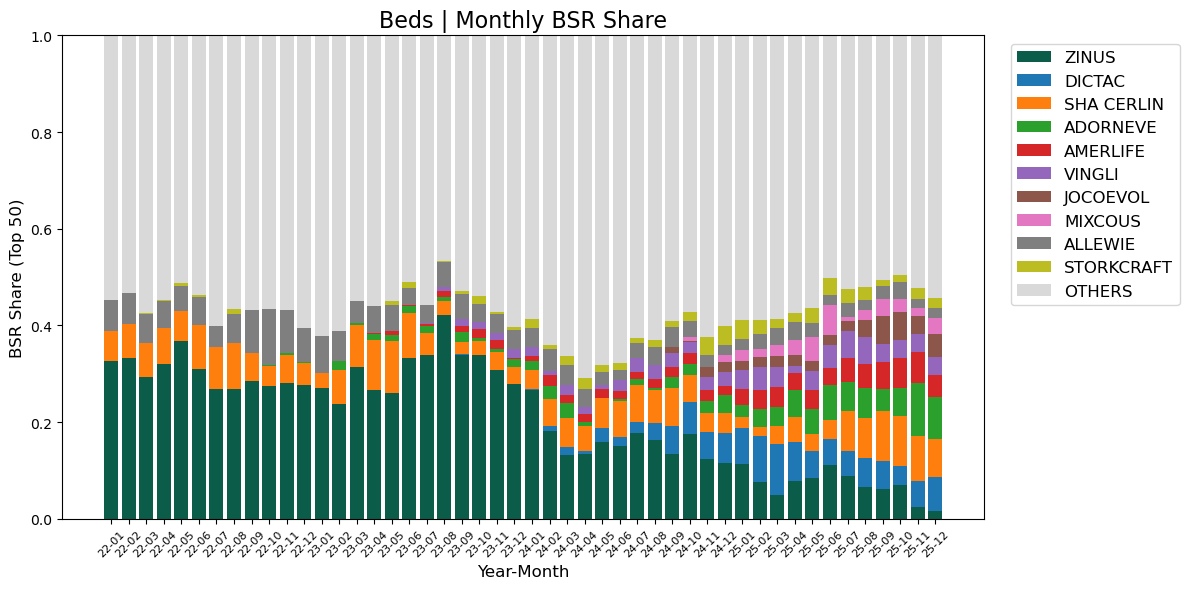

['ZINUS', 'NOVILLA', 'MLILY', 'BEST PRICE MATTRESS', 'ROLANSTAR', 'NAPQUEEN', 'MOLBIUS', 'AMAZON BASICS', 'FDW', 'GAESTE', 'OTHERS']


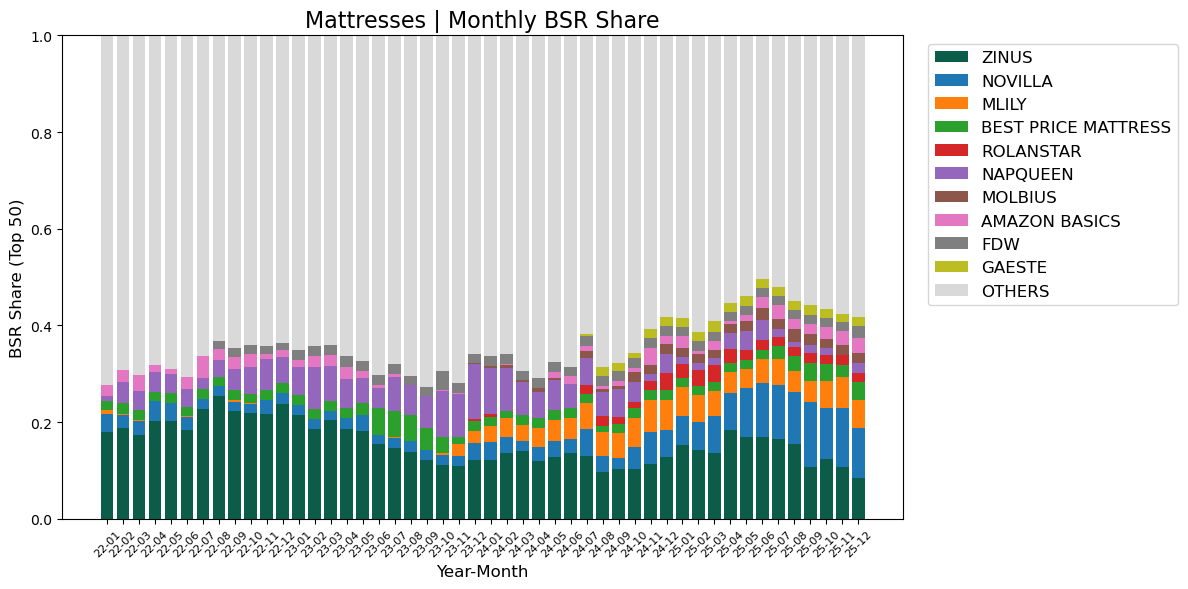

In [194]:
ZINUS_COLOR  = '#0B5D4A'   # dark jade
OTHERS_COLOR = '#D9D9D9'   # gray

df_plot = brand_share_m[brand_share_m['yr_month'] >= '22-01'].copy()

for cat, sub in df_plot.groupby('bsr_ctgry'):
    sub = sub.copy()

    # -----------------------------
    # (A) category별 2025 기준 brand 순서 계산
    # -----------------------------
    yrm = sub['yr_month'].astype(str)
    sub_2025 = sub[yrm.str.startswith('2025') | yrm.str.startswith('25-')].copy()

    order_2025 = (
        sub_2025
        .groupby('brand_new')['bsr_share']
        .mean()
        .reset_index(name='ref_share')
    )

    zinus_list = ['ZINUS']
    others_list = ['OTHERS']

    rest_list = (
        order_2025[
            (order_2025['brand_new'] != 'ZINUS') &
            (order_2025['brand_new'] != 'OTHERS')
        ]
        .sort_values('ref_share', ascending=False)['brand_new']
        .tolist()
    )

    ordered_cols_base = zinus_list + rest_list + others_list  # ✅ category별 기준 순서
    print(ordered_cols_base)

    # -----------------------------
    # (B) pivot 만들고, 위 순서 적용
    # -----------------------------
    piv = (
        sub.pivot(index='yr_month', columns='brand_new', values='bsr_share')
           .fillna(0)
           .sort_index()
    )
    #print(piv)

    # 해당 piv에 실제로 존재하는 컬럼만 (안전)
    cols_in_piv = piv.columns.tolist()
    ordered_cols = [c for c in ordered_cols_base if c in cols_in_piv]

    # 2025에 없었지만 실제로 존재하는 브랜드(예: 2024만 등장) 뒤에 붙이기
    leftover = [c for c in cols_in_piv if c not in ordered_cols]
    ordered_cols = ordered_cols + leftover

    piv = piv[ordered_cols]
    # --- 누적 막대그래프 ---
    plt.figure(figsize=(12, 6))
    bottom = np.zeros(len(piv))

    for c in ordered_cols:
        c_up = str(c).strip().upper()

        values = piv[c].values
        x_pos = piv.index.astype(str)
        y_pos = bottom + values / 2

        if c_up == 'OTHERS':
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label='OTHERS',
                color=OTHERS_COLOR
            )
        elif c_up == 'ZINUS':
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label='ZINUS',
                color=ZINUS_COLOR
            )
        else:
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label=str(c)
            )

        if False: # 주석 처리      
            # ✅ 퍼센트 라벨 표시 (1% 이상만)
            for i, v in enumerate(values):
                if v >= 0.05:  # 1% 미만은 표시 안 함
                    plt.text(
                        x_pos[i],
                        y_pos[i],
                        f"{v*100:.1f}%",
                        ha='center',
                        va='center',
                        fontsize=5,
                        color='white' if c_up != 'OTHERS' else 'black',
                        fontweight='bold'
                    )
   
        bottom = bottom + values

    plt.title(f"{cat} | Monthly BSR Share", fontsize=16)
    plt.xlabel("Year-Month", fontsize=12)
    plt.ylabel("BSR Share (Top 50)", fontsize=12)
    plt.ylim(0, 1)

    plt.xticks(rotation=45, fontsize=8)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

#### 2. Review rating, review count, Price, 1P3P

In [33]:
df2 = df.copy()

df2['bsr_date'] = pd.to_datetime(df2['bsr_date'], errors='coerce')
df2['year'] = df2['bsr_date'].dt.year

In [35]:
print(df2)

       parent_asin   bsr_ctgry        asin  rank   bsr_date           brand  \
0       B0D5RC39TY        Beds  B079PG6VMW    32 2022-09-12          Others   
1       B07RFGWXNM  Bed Frames  B07RFGWXNM     8 2022-09-12          Others   
2       B0FR9HNG1V  Mattresses  B07BV29J5N    23 2022-09-12        COOL GEL   
3       B0CTR6GDNQ  Bed Frames  B08VN6W69N    15 2022-09-12       YAHEETECH   
4       B09X75ZWGG        Beds  B004LQ1PAI    28 2022-09-12          Others   
...            ...         ...         ...   ...        ...             ...   
325851  B0DYZ28XZV  Mattresses  B074QTSBS2     2 2021-01-01           ZINUS   
325852  B0D5B3DVZL        Beds  B07S6SDM2V    18 2021-01-01          Others   
325853  B08C2RJTLY  Bed Frames  B08C2RJTLY    42 2021-01-01  AMOLIFE FAMILY   
325854  B0B3DC36K1        Beds  B00TPI7JNO    22 2021-01-01          Others   
325855  B07YQN9R32        Beds  B06WW5586Q    32 2021-01-01           ZINUS   

        brand_raw brand_raw_org  \
0          Other

In [71]:
df2[df2['brand_raw_org']=='FLUEST']

,parent_asin,bsr_ctgry,asin,rank,bsr_date,brand,brand_raw,brand_raw_org,title,image_url,...,asin_cnt_brand_dt,asin_cnt_brand_dt_rank,asin_cnt_ttl_dt,asin_cnt_ttl_dt_rank,brand_legend_ord,retail_price,rating,review_count,seller_type,year
8194,B0CGKPHL7D,Beds,B0CGKPHL7D,10,2025-12-30,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame with Headboard and Foot...,https://m.media-amazon.com/images/I/710OAO+ucU...,...,2,0,50,0,52,79.99,3.6,3335.0,3P,2025
8273,B0FNN2454Z,Bed Frames,B0D8J9QWH1,20,2025-12-30,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame with Headboard PU Leath...,https://m.media-amazon.com/images/I/81mJZ5SuVh...,...,3,1,50,0,52,98.99,4.3,1456.0,3P,2025
8278,B0CGKPHL7D,Beds,B0CGKPHL7D,10,2025-12-30,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame with Headboard and Foot...,https://m.media-amazon.com/images/I/710OAO+ucU...,...,2,0,50,0,52,79.99,3.6,3335.0,3P,2025
8307,B0FQPHQXN9,Bed Frames,B0DWRJJG7Z,37,2025-12-30,FLUEST,FLUEST,FLUEST,"Fluest Queen Bed Frame, Platform Bed Frame wit...",https://m.media-amazon.com/images/I/81+QlytA71...,...,3,0,50,0,52,120.99,4.4,211.0,3P,2025
8316,B0G73KH798,Beds,B0CGJ3GFJ6,4,2025-12-30,FLUEST,FLUEST,FLUEST,Fluest Twin Bed Frame with Headboard and Footb...,https://m.media-amazon.com/images/I/81yk9J0YoK...,...,2,1,50,0,52,61.99,4.1,813.0,3P,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255093,B0BXH71J61,Beds,B0BXH71J61,44,2023-03-17,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame Upholstered Bed Frame P...,https://images-na.ssl-images-amazon.com/images...,...,1,1,50,0,52,NaN,NaN,NaN,None,2023
255173,B0BXH71J61,Beds,B0BXH71J61,45,2023-03-16,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame Upholstered Bed Frame P...,https://images-na.ssl-images-amazon.com/images...,...,1,1,50,0,52,NaN,NaN,NaN,None,2023
255475,B0BXH71J61,Beds,B0BXH71J61,47,2023-03-15,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame Upholstered Bed Frame P...,https://images-na.ssl-images-amazon.com/images...,...,1,1,50,0,52,NaN,NaN,NaN,None,2023
255498,B0BXH71J61,Beds,B0BXH71J61,41,2023-03-14,FLUEST,FLUEST,FLUEST,Fluest Queen Bed Frame Upholstered Bed Frame P...,https://images-na.ssl-images-amazon.com/images...,...,1,1,50,0,52,NaN,NaN,NaN,None,2023


In [37]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_brand_2025 = {
    cat: get_brand_share_by_category(df2, category=cat, year=2025)
    for cat in categories
}

In [73]:
#print(top10_brand_2025)
top10_brand_2025['Beds']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
147,ZINUS,2543,21449,0.118560,11.856031
114,SHA CERLIN,1288,21449,0.060049,6.004942
29,DICTAC,1227,21449,0.057205,5.720546
1,ADORNEVE,1093,21449,0.050958,5.095809
4,AMERLIFE,1027,21449,0.047881,4.788102
134,VINGLI,755,21449,0.035200,3.519978
94,MILLIARD,745,21449,0.034734,3.473355
92,MELLOW,734,21449,0.034221,3.422071
70,JOCOEVOL,602,21449,0.028067,2.806658
46,FLUEST,576,21449,0.026854,2.685440


In [37]:
# Category별로 Top Brand의 data 추출하기
df_2025 = df2[df2['year']==2025].copy()

for cat, df_top10 in top10_brand_2025.items():
#    if cat != 'Bed Frames': 
#        continue
    top_brands = df_top10['brand_raw_org'].unique().tolist()
    
    # ① 해당 category만 필터링
    df_cat = df_2025[df_2025['bsr_ctgry'] == cat].copy()
    if df_cat.empty:
        continue

    # ② 해당 category의 Top10 브랜드만 필터링
    df_cat_top10 = df_cat[df_cat['brand_raw_org'].isin(top_brands)].copy()

    # 동일 시간 중복이면 "마지막"이 남도록 정렬 후 tail(1)
    df_cat_top10 = df_cat_top10.sort_values(['asin', 'bsr_date'])

    df_latest = (
        df_cat_top10
        .groupby(['bsr_ctgry','asin'], as_index=False)
        .tail(1)
    )
    
    # 1) (category, brand)별 seller_type(1P/2P/3P) ASIN 개수 → wide 형태
    seller_cnt = (
        df_latest
        .pivot_table(
            index=['bsr_ctgry', 'brand_raw_org'],
            columns='seller_type',
            values='asin',
            aggfunc=pd.Series.nunique,
            fill_value=0
        )
        .reset_index()
    )
    #print(seller_cnt)

        # 2) 평균 지표 계산
    metrics = (
        df_latest
        .groupby(['bsr_ctgry', 'brand_raw_org'], as_index=False)
        .agg(
            avg_rank=('rank', 'mean'),
            avg_rating=('rating', 'mean'),
            avg_retail_price=('retail_price', 'mean'),
            product_item_cnt=('asin', 'nunique')   # 전체 ASIN 수(참고용)
        )
    )
    #print(metrics)   

    # 3) 결합
    result = (
        metrics
        .merge(seller_cnt, on=['bsr_ctgry', 'brand_raw_org'], how='left')
    )
    print(result) 
    print(f"\n==== Category: {cat} | unique_asin={df_latest['asin'].nunique()} ====\n\n")


  bsr_ctgry brand_raw_org   avg_rank  avg_rating  avg_retail_price  \
0      Beds      ADORNEVE     34.475    4.400000        151.449459   
1      Beds      AMERLIFE       32.5    4.404762        454.712857   
2      Beds        DICTAC   35.69697    4.180645        169.012903   
3      Beds        FLUEST      10.75    4.050000         75.490000   
4      Beds      JOCOEVOL  29.090909    4.300000        208.353000   
5      Beds        MELLOW        1.5    4.600000        134.990000   
6      Beds      MILLIARD       34.0    4.500000        267.490000   
7      Beds    SHA CERLIN  28.628571    4.403030        158.545152   
8      Beds        VINGLI       31.5    4.137500        159.450000   
9      Beds         ZINUS  39.473684    4.602632        151.842105   

   product_item_cnt  1P  3P  
0                40   0  37  
1                24   0  21  
2                33   0  31  
3                 8   0   4  
4                11   0  10  
5                 2   2   0  
6                 2

#### 3. Brand별 매출 

In [41]:
df3 = df.copy()

df3['bsr_date'] = pd.to_datetime(df3['bsr_date'], errors='coerce')
df3['year'] = df3['bsr_date'].dt.year

In [43]:
print(df3)

       parent_asin   bsr_ctgry        asin  rank   bsr_date           brand  \
0       B0D5RC39TY        Beds  B079PG6VMW    32 2022-09-12          Others   
1       B07RFGWXNM  Bed Frames  B07RFGWXNM     8 2022-09-12          Others   
2       B0FR9HNG1V  Mattresses  B07BV29J5N    23 2022-09-12        COOL GEL   
3       B0CTR6GDNQ  Bed Frames  B08VN6W69N    15 2022-09-12       YAHEETECH   
4       B09X75ZWGG        Beds  B004LQ1PAI    28 2022-09-12          Others   
...            ...         ...         ...   ...        ...             ...   
325851  B0DYZ28XZV  Mattresses  B074QTSBS2     2 2021-01-01           ZINUS   
325852  B0D5B3DVZL        Beds  B07S6SDM2V    18 2021-01-01          Others   
325853  B08C2RJTLY  Bed Frames  B08C2RJTLY    42 2021-01-01  AMOLIFE FAMILY   
325854  B0B3DC36K1        Beds  B00TPI7JNO    22 2021-01-01          Others   
325855  B07YQN9R32        Beds  B06WW5586Q    32 2021-01-01           ZINUS   

        brand_raw brand_raw_org  \
0          Other

In [53]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_2025 = {
    cat: get_brand_share_by_category(df3, category=cat, year=2025)
    for cat in categories
}

In [63]:
for cat, df_top in top10_2025.items():
    top10_2025[cat]['brand_raw_org'] = (
        df_top['brand_raw_org']
        .replace({'AMAZON BASICS': 'AMAZONBASICS'})
    )

In [77]:
top10_2025['Bed Frames']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
2,ALLEWIE,3134,21418,0.146326,14.632552
100,ZINUS,1899,21418,0.088664,8.866374
95,YAHEETECH,1266,21418,0.059109,5.910916
80,SHA CERLIN,1214,21418,0.056681,5.668130
33,FURNULEM,1060,21418,0.049491,4.949108
60,MELLOW,802,21418,0.037445,3.744514
3,AMAZONBASICS,752,21418,0.035111,3.511065
67,OLEVS,685,21418,0.031982,3.198244
29,FLUEST,578,21418,0.026987,2.698665
88,VECELO,516,21418,0.024092,2.409189


In [69]:
# Get 2025 sales of top brands
df_sales['Brand_up'] = df_sales['Brand'].str.upper().str.strip()

for cat, df_top10 in top10_2025.items():
    #if cat != 'Mattresses': 
    #    continue
    #df_top10['brand_raw_org'] = df['brand_raw_org'].replace({'AMAZON BASICS':'AMAZONBASICS'})

    top_brands = df_top10['brand_raw_org'].unique().tolist()
    print(top_brands)

    # ① 해당 category만 필터링
    df_cat = df_sales[df_sales['SubCategory'] == cat].copy()
    if df_cat.empty:
        continue
    
    # ② 해당 category의 Top10 브랜드만 필터링
    df_cat_top10 = df_cat[df_cat['Brand_up'].isin(top_brands)].copy()

    # 2) Brand별 매출 합
    top_brand_sales = (
        df_cat_top10
        .groupby(['SubCategory', 'Brand_up'], as_index=False)
        .agg(
            sales=('RetailSales', 'sum'),
            qty=('UnitsSold', 'sum')
        )
        .sort_values('sales', ascending=False)
    )

    print(top_brand_sales)

['ZINUS', 'SHA CERLIN', 'DICTAC', 'ADORNEVE', 'AMERLIFE', 'VINGLI', 'MILLIARD', 'MELLOW', 'JOCOEVOL', 'FLUEST']
  SubCategory    Brand_up        sales     qty
7        Beds  SHA CERLIN  52777053.56  370267
9        Beds       ZINUS  30451993.17  185201
1        Beds    AMERLIFE  25023757.59   76840
5        Beds      MELLOW  23163230.20  159459
3        Beds      FLUEST  17407790.34  177015
4        Beds    JOCOEVOL  14985839.22   76835
2        Beds      DICTAC  13526334.96   77618
0        Beds    ADORNEVE   9866708.69   67550
8        Beds      VINGLI   2299817.36   14425
6        Beds    MILLIARD   1162378.73    4626
['ALLEWIE', 'ZINUS', 'YAHEETECH', 'SHA CERLIN', 'FURNULEM', 'MELLOW', 'AMAZONBASICS', 'OLEVS', 'FLUEST', 'VECELO']
  SubCategory      Brand_up        sales     qty
1  Bed Frames  AMAZONBASICS  20348014.80  275871
8  Bed Frames         ZINUS  19129495.89  258489
0  Bed Frames       ALLEWIE   4778271.60   35520
3  Bed Frames        MELLOW   2334269.38   15336
7  Bed Fram